In [130]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

In [131]:
import pickle

with open('/Users/anshgrover/AIDA3/PINN-tutorial/data/massdamper_data.pkl', 'rb') as f:
    data = pickle.load(f)

data_sampled_random_with_noise = data['data_sampled_random_with_noise']
model_name = 'No external force'
sparsity   = 'sparsity 1.667Hz'

t_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['t'], dtype=torch.float64)
y_obs = torch.tensor(data_sampled_random_with_noise[model_name][sparsity]['x'], dtype=torch.float64)
n = len(t_obs)
p = 1

delta_true = 0.075
omega0_true = 0.3162
sigma_obs = 0.1

print(f"n = {n}, t range: [{t_obs[0]:.2f}, {t_obs[-1]:.2f}]")

n = 100, t range: [0.00, 60.00]


In [132]:
def rbf_kernel(t1, t2, log_sigma_f2, log_l):
    sigma_f2 = torch.exp(log_sigma_f2)
    l = torch.exp(log_l)
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l)

In [133]:
def neg_log_marginal_likelihood(log_sigma_f2, log_l, log_sigma2, t, y):
    n = len(t)
    K = rbf_kernel(t, t, log_sigma_f2, log_l)
    sigma2 = torch.exp(log_sigma2)
    C = K + sigma2 * torch.eye(n)

    L = torch.linalg.cholesky(C)
    alpha = torch.cholesky_solve(y.unsqueeze(1), L).squeeze(1)

    data_fit = 0.5 * y @ alpha
    complexity = torch.log(torch.diagonal(L)).sum()
    const = 0.5 * n * np.log(2 * np.pi)

    return data_fit + complexity + const

In [134]:
log_sigma_f2 = torch.tensor(0.0, requires_grad=True)
log_l = torch.tensor(np.log(5.0), requires_grad=True)
log_sigma2 = torch.tensor(np.log(0.1**2), requires_grad=True)

params = [log_sigma_f2, log_l, log_sigma2]
optimizer = torch.optim.LBFGS(params, lr=1.0, max_iter=200, line_search_fn='strong_wolfe')

def closure():
    optimizer.zero_grad()
    loss = neg_log_marginal_likelihood(log_sigma_f2, log_l, log_sigma2, t_obs, y_obs)
    loss.backward()
    return loss

optimizer.step(closure)

tensor(-31.3172, grad_fn=<AddBackward0>)

In [135]:
sigma_f2_star = torch.exp(log_sigma_f2).item()
l_star = torch.exp(log_l).item()
sigma2_star = torch.exp(log_sigma2).item()

print(f"sigma_f^2* = {sigma_f2_star:.4f}")
print(f"l*         = {l_star:.4f}")
print(f"sigma^2*   = {sigma2_star:.4f}  (true noise variance = {sigma_obs**2:.4f})")

sigma_f^2* = 0.1800
l*         = 39.9775
sigma^2*   = 0.0091  (true noise variance = 0.0100)


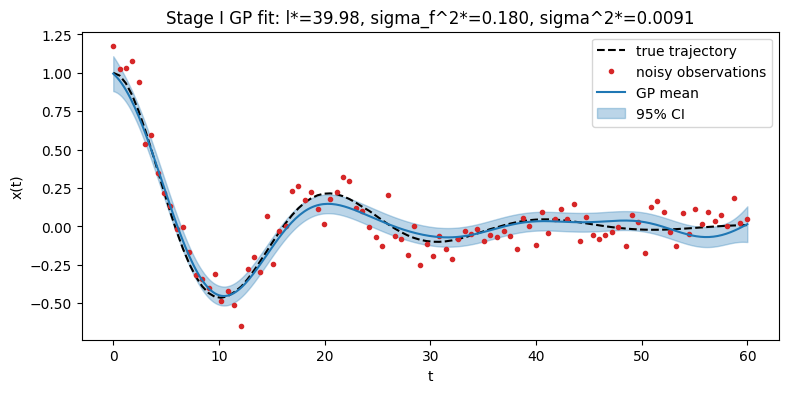

In [136]:
with torch.no_grad():
    K = rbf_kernel(t_obs, t_obs, log_sigma_f2, log_l)
    C = K + torch.exp(log_sigma2) * torch.eye(n)
    L = torch.linalg.cholesky(C)
    alpha = torch.cholesky_solve(y_obs.unsqueeze(1), L).squeeze(1)

    t_grid = torch.linspace(0, T, 300)
    k_star = rbf_kernel(t_grid, t_obs, log_sigma_f2, log_l)
    mean_pred = k_star @ alpha

    v = torch.cholesky_solve(k_star.T, L)
    k_star_star = rbf_kernel(t_grid, t_grid, log_sigma_f2, log_l)
    var_pred = torch.diagonal(k_star_star) - torch.sum(k_star * v.T, dim=1)
    std_pred = torch.sqrt(torch.clamp(var_pred, min=0))

plt.figure(figsize=(9, 4))
plt.plot(t_obs, x_true_np, 'k--', label='true trajectory')
plt.plot(t_obs, y_obs_np, '.', color='tab:red', label='noisy observations')
plt.plot(t_grid, mean_pred, color='tab:blue', label='GP mean')
plt.fill_between(t_grid, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred,
                  alpha=0.3, color='tab:blue', label='95% CI')
plt.xlabel('t'); plt.ylabel('x(t)'); plt.legend()
plt.title(f"Stage I GP fit: l*={l_star:.2f}, sigma_f^2*={sigma_f2_star:.3f}, sigma^2*={sigma2_star:.4f}")
plt.show()

In [137]:
# freeze the fitted Stage I hyperparameters so no gradient flows into them anymore
log_sigma_f2_star = log_sigma_f2.detach()
log_l_star = log_l.detach()
log_sigma2_star = log_sigma2.detach()

def gp_mean_fn(t_query, t_train, y_train, log_sigma_f2, log_l, log_sigma2):
    n_train = len(t_train)
    K = rbf_kernel(t_train, t_train, log_sigma_f2, log_l)
    C = K + torch.exp(log_sigma2) * torch.eye(n_train)
    L = torch.linalg.cholesky(C)
    alpha = torch.cholesky_solve(y_train.unsqueeze(1), L).squeeze(1)
    k_star = rbf_kernel(t_query, t_train, log_sigma_f2, log_l)
    return k_star @ alpha

In [138]:
t_query = t_obs.clone().detach().requires_grad_(True)

x_hat = gp_mean_fn(t_query, t_obs, y_obs, log_sigma_f2_star, log_l_star, log_sigma2_star)

xdot_hat = torch.autograd.grad(
    x_hat, t_query, grad_outputs=torch.ones_like(x_hat), create_graph=True
)[0]

xddot_hat = torch.autograd.grad(
    xdot_hat, t_query, grad_outputs=torch.ones_like(xdot_hat), create_graph=True
)[0]

# detach these are now fixed constants for Stage II, no further need to
# differentiate through t
x_hat = x_hat.detach()
xdot_hat = xdot_hat.detach()
xddot_hat = xddot_hat.detach()

print(x_hat.shape, xdot_hat.shape, xddot_hat.shape)

torch.Size([100]) torch.Size([100]) torch.Size([100])


In [139]:
def g_n_GP(theta, x_hat, xdot_hat, xddot_hat):
    delta, omega0 = theta[0], theta[1]
    r = xddot_hat + 2*delta*xdot_hat + omega0**2 * x_hat
    return torch.mean(r**2)

In [148]:
sigma_r2 = 0.001   # 100x smaller than before
theta_prior = torch.tensor([0.1, 0.3])
Sigma_prior_inv = torch.diag(torch.tensor([1/0.1**2, 1/0.2**2]))

def neg_log_posterior_v2(theta, x_hat, xdot_hat, xddot_hat):
    gn = g_n_GP(theta, x_hat, xdot_hat, xddot_hat)
    data_term = (n / (2 * sigma_r2)) * gn
    prior_term = 0.5 * (theta - theta_prior) @ Sigma_prior_inv @ (theta - theta_prior)
    return data_term + prior_term

theta2 = theta_prior.clone().detach().requires_grad_(True)
optimizer3 = torch.optim.LBFGS([theta2], lr=1.0, max_iter=200, line_search_fn='strong_wolfe')

def closure3():
    optimizer3.zero_grad()
    loss = neg_log_posterior_v2(theta2, x_hat, xdot_hat, xddot_hat)
    loss.backward()
    return loss

optimizer3.step(closure3)
theta_map = theta2.detach()

H2 = torch.autograd.functional.hessian(
    lambda th: neg_log_posterior_v2(th, x_hat, xdot_hat, xddot_hat), theta_map2
)
Sigma_theta2 = torch.linalg.inv(H2)
std_theta = torch.sqrt(torch.diagonal(Sigma_theta2))

print(f"theta_MAP: delta={theta_map[0]:.4f}, omega0={theta_map[1]:.4f}")
print(f"true:      delta={delta_true:.4f}, omega0={omega0_true:.4f}")
print(f"delta:  {theta_map[0]:.4f} +/- {1.96*std_theta[0]:.4f} (95% CI)")
print(f"omega0: {theta_map[1]:.4f} +/- {1.96*std_theta[1]:.4f} (95% CI)")

theta_MAP: delta=0.0714, omega0=0.2824
true:      delta=0.0750, omega0=0.3162
delta:  0.0714 +/- 0.0486 (95% CI)
omega0: 0.2824 +/- 0.0477 (95% CI)


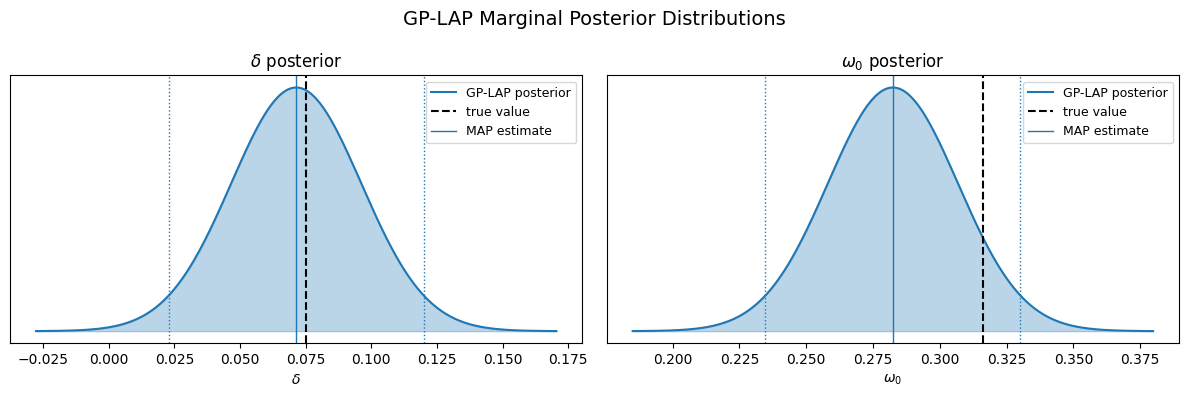

In [149]:
import matplotlib.pyplot as pp
from scipy.stats import norm

mean_np = theta_map.numpy()
std_np = std_theta.numpy()
true_vals = [delta_true, omega0_true]
param_names = [r'$\delta$', r'$\omega_0$']

fig, axes = pp.subplots(1, 2, figsize=(12, 4))

for i, ax in enumerate(axes):
    x_grid = np.linspace(mean_np[i] - 4*std_np[i], mean_np[i] + 4*std_np[i], 300)
    pdf = norm.pdf(x_grid, loc=mean_np[i], scale=std_np[i])

    ax.plot(x_grid, pdf, color='tab:blue', label='GP-LAP posterior')
    ax.fill_between(x_grid, pdf, alpha=0.3, color='tab:blue')

    ci_lo, ci_hi = mean_np[i] - 1.96*std_np[i], mean_np[i] + 1.96*std_np[i]
    ax.axvline(ci_lo, color='tab:blue', linestyle=':', linewidth=1)
    ax.axvline(ci_hi, color='tab:blue', linestyle=':', linewidth=1)

    ax.axvline(true_vals[i], color='k', linestyle='--', label='true value')
    ax.axvline(mean_np[i], color='tab:blue', linestyle='-', linewidth=1, label='MAP estimate')

    ax.set_title(f'{param_names[i]} posterior')
    ax.set_xlabel(param_names[i])
    ax.set_yticks([])
    ax.legend(fontsize=9)

fig.suptitle('GP-LAP Marginal Posterior Distributions', fontsize=14)
pp.tight_layout()
pp.show()

In [150]:
def mass_damper_deriv(delta, omega0, t):
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    return np.exp(-delta*t) * 2*A*(-delta*np.cos(phi + omega*t) - omega*np.sin(phi + omega*t))

def mass_damper_accel(delta, omega0, t):
    # directly from the ODE itself: x'' = -2*delta*x' - omega0^2*x
    x = mass_damper(delta, omega0, t)
    xdot = mass_damper_deriv(delta, omega0, t)
    return -2*delta*xdot - omega0**2*x

xdot_true_np = mass_damper_deriv(delta_true, omega0_true, t_obs_np)
xddot_true_np = mass_damper_accel(delta_true, omega0_true, t_obs_np)

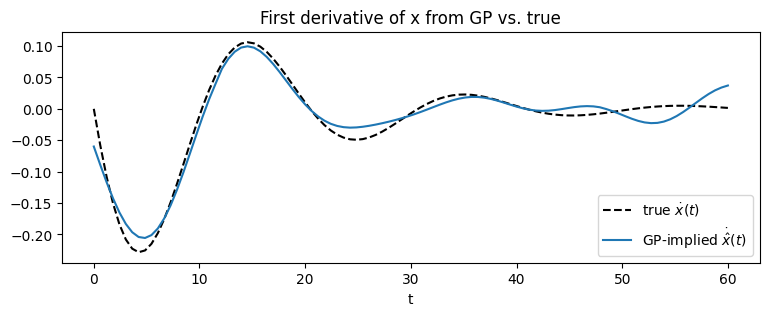

mean abs error (velocity): 0.01144
mean abs error (velocity) relative to true amplitude: 0.158


In [153]:
plt.figure(figsize=(9, 3))
plt.plot(t_obs_np, xdot_true_np, 'k--', label='true $\\dot{x}(t)$')
plt.plot(t_obs_np, xdot_hat.numpy(), color='tab:blue', label='GP-implied $\\dot{\\hat{x}}(t)$')
plt.legend(); plt.xlabel('t')
plt.title('First derivative of x from GP vs. true')
plt.show()

resid_vel = xdot_hat.numpy() - xdot_true_np
print(f"mean abs error (velocity): {np.mean(np.abs(resid_vel)):.5f}")
print(f"mean abs error (velocity) relative to true amplitude: {np.mean(np.abs(resid_vel))/np.std(xdot_true_np):.3f}")

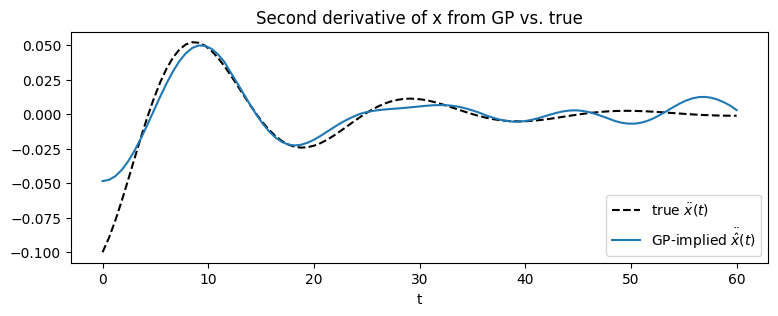

mean abs error (acceleration): 0.00556
mean abs error (acceleration) relative to true amplitude: 0.227


In [154]:
plt.figure(figsize=(9, 3))
plt.plot(t_obs_np, xddot_true_np, 'k--', label='true $\\ddot{x}(t)$')
plt.plot(t_obs_np, xddot_hat.numpy(), color='tab:blue', label='GP-implied $\\ddot{\\hat{x}}(t)$')
plt.legend(); plt.xlabel('t')
plt.title('Second derivative of x from GP vs. true')
plt.show()

resid_accel = xddot_hat.numpy() - xddot_true_np
print(f"mean abs error (acceleration): {np.mean(np.abs(resid_accel)):.5f}")
print(f"mean abs error (acceleration) relative to true amplitude: {np.mean(np.abs(resid_accel))/np.std(xddot_true_np):.3f}")